In [1]:
from pathlib import Path

from decent_bench import benchmark
from decent_bench.utils.checkpoint_manager import CheckpointManager

In [2]:
checkpoint_dir = "/home/ubuntu/github/decent-bench/examples/nim/results/heterogeneous_2/mnist_bs_32_ss_0.01_hg_True_tp_2"
checkpoint_dir = Path(checkpoint_dir)
if not checkpoint_dir.is_dir():
    raise ValueError(f"Checkpoint directory {checkpoint_dir} does not exist")

In [3]:
checkpoint_manager = CheckpointManager(checkpoint_dir=checkpoint_dir)

In [4]:
metrics_result = checkpoint_manager.load_metrics_result()

Output()

[04/02/26 02:48:41] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=233443;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=177398;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=214062;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=547872;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+                                     
                             | Metric (statistic)      | DGD                 |                                     
                             +=========================+=====================+                                     
                             | consensus error (min)   | 8.20e-03 ± 3.73e-04 |                                     
                             +-------------------------+---------------------+                                     
                             | consensus error (avg)   | 9.07e-03 ± 1.15e-04 |                                     
                             +-------------------------+---------------------+                                     
                             | consensus error (max)   | 1.02e-02 ± 7.80e-04 |                                     
                             +-------------------------+---------------------+                                     
                             | nr gradient calls (avg) | 3.20e+04 ± 0.00e+00 |                                     
                             +-------------------------+---------------------+                                     
                             | nr gradient calls (sum) | 1.60e+05 ± 0.00e+00 |                                     
                             +-------------------------+---------------------+                                     
                             | nr sent messages (avg)  | 4.00e+03 ± 0.00e+00 |                                     
                             +-------------------------+---------------------+                                     
                             | nr sent messages (sum)  | 2.00e+04 ± 0.00e+00 |                                     
                             +-------------------------+---------------------+                                     
                             | accuracy (min)          | 24.39% ± 0.77%      |                                     
                             +-------------------------+---------------------+                                     
                             | accuracy (avg)          | 25.61% ± 0.71%      |                                     
                             +-------------------------+---------------------+                                     
                             | accuracy (max)          | 27.45% ± 1.01%      |                                     
                             +-------------------------+---------------------+                                     
                             | precision (min)         | 24.39% ± 0.77%      |                                     
                             +-------------------------+---------------------+                                     
                             | precision (avg)         | 25.61% ± 0.71%      |                                     
                             +-------------------------+---------------------+                                     
                             | precision (max)         | 27.45% ± 1.01%      |                                     
                             +-------------------------+---------------------+                                     
                             | recall (min)            | 24.39% ± 0.77%      |                                     
                             +-------------------------+---------------------+                                     
                             | recall (avg)            | 25.61% ± 0.71%      |                   

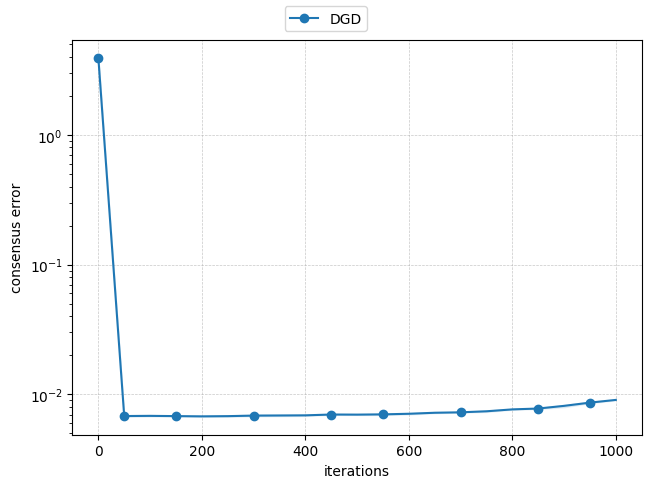

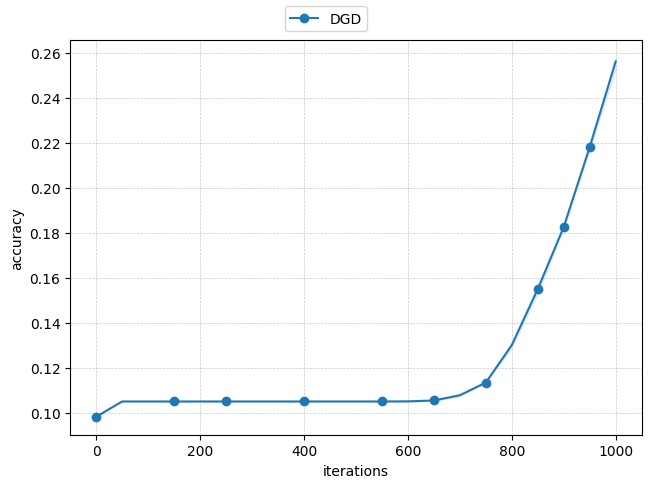

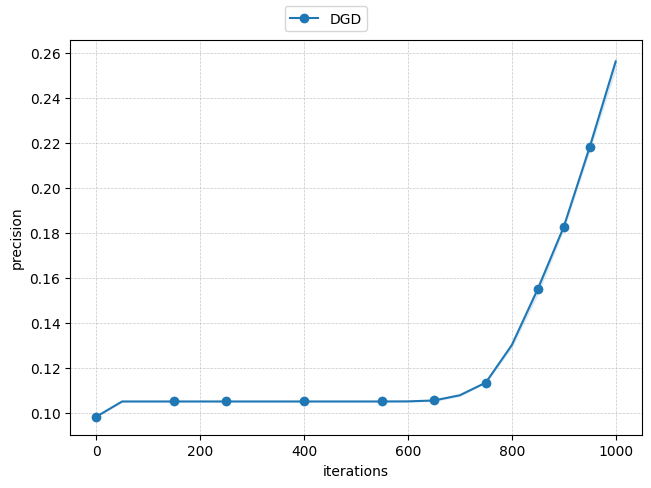

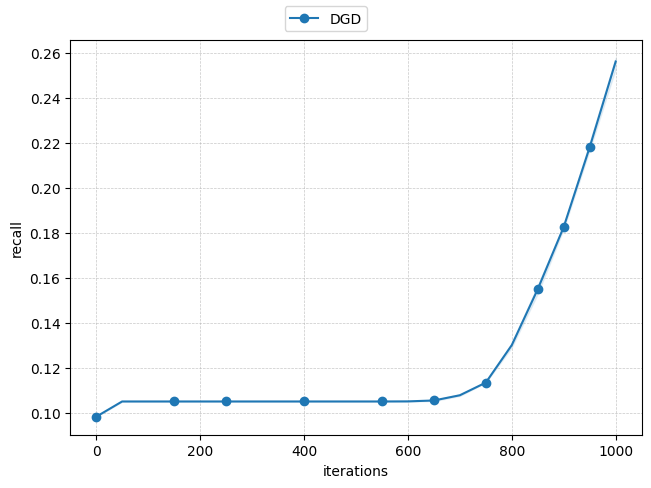

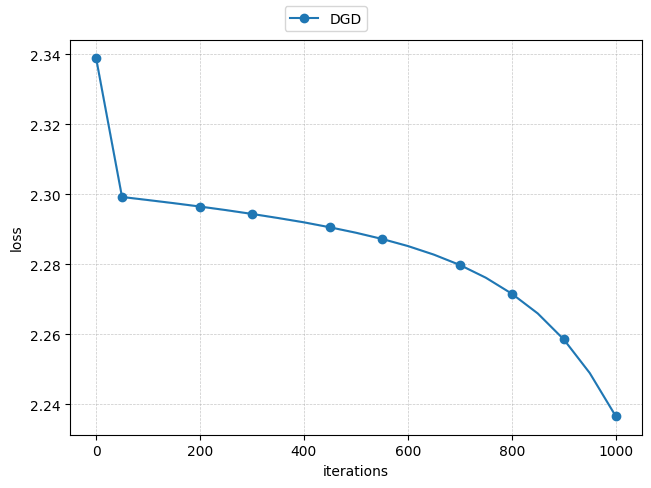

In [5]:
algorithms_to_include = [
    "DGD",
    # "KGT",
    # "LED",
    # "LT-ADMM-10",
    # "LT-ADMM-5",
    # "LT-ADMM-1",
    # "LT-ADMM-VR",
    # "ProxSkip",
]
new_metrics_result = benchmark.MetricResult(None, metrics_result.table_metrics, metrics_result.plot_metrics, None, None)

# Only include certain algorithms
def issubstring(substring: str):
    return any(alg in substring for alg in algorithms_to_include)


new_metrics_result.agent_metrics = {
    alg: metrics for alg, metrics in metrics_result.agent_metrics.items() if issubstring(alg.name)
}
new_metrics_result.table_results = {
    alg: table for alg, table in metrics_result.table_results.items() if issubstring(alg.name)
}
new_metrics_result.plot_results = {alg: plot for alg, plot in metrics_result.plot_results.items() if issubstring(alg.name)}
benchmark.display_metrics(metrics_result=new_metrics_result)

[04/02/26 02:48:46] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=822823;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=590324;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=155131;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=850051;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | Metric (statistic)      | KGT-10LS            | KGT-1LS             |               
                             KGT-5LS             |                                                                 
                             +=========================+=====================+=====================+=              
                             ====================+                                                                 
                             | consensus error (min)   | 7.61e-08 ± 3.68e-09 | 7.33e-08 ± 6.22e-09 |               
                             7.45e-08 ± 5.98e-09 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (avg)   | 7.87e-08 ± 2.84e-09 | 7.59e-08 ± 3.91e-09 |               
                             7.79e-08 ± 4.55e-09 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (max)   | 8.24e-08 ± 6.22e-09 | 7.98e-08 ± 1.95e-09 |               
                             8.23e-08 ± 8.46e-09 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (avg) | 3.20e+05 ± 0.00e+00 | 3.20e+04 ± 0.00e+00 |               
                             1.60e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (sum) | 1.60e+06 ± 0.00e+00 | 1.60e+05 ± 0.00e+00 |               
                             8.00e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (avg)  | 4.00e+03 ± 0.00e+00 | 4.00e+03 ± 0.00e+00 |               
                             4.00e+03 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (sum)  | 2.00e+04 ± 0.00e+00 | 2.00e+04 ± 0.00e+00 |               
                             2.00e+04 ± 0.00e+00 |                                               

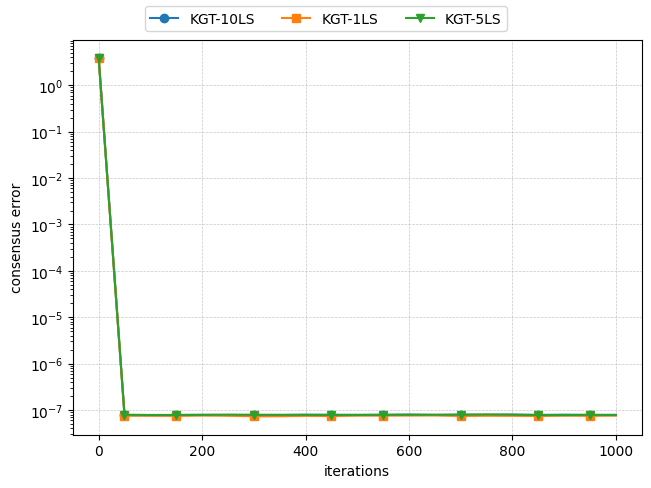

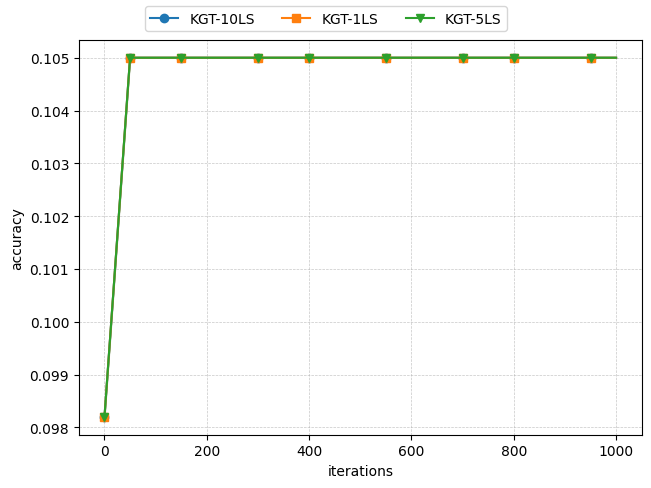

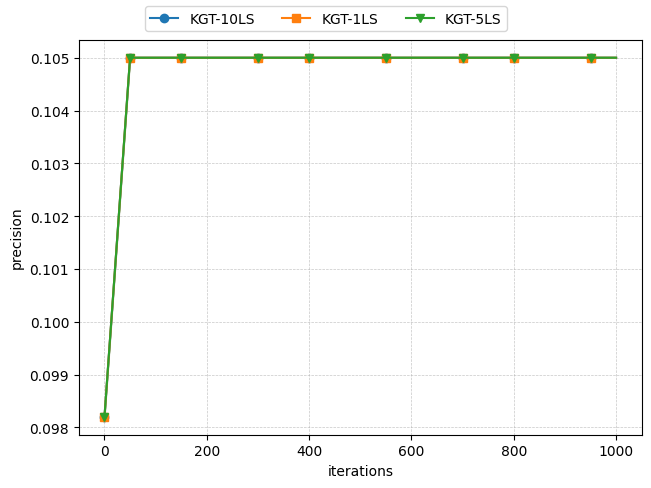

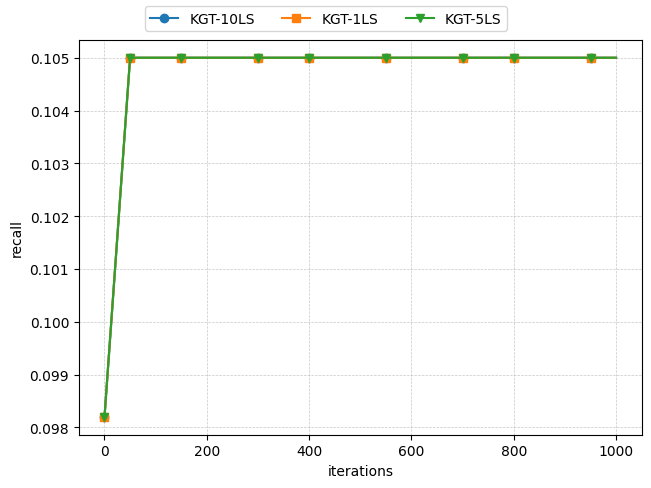

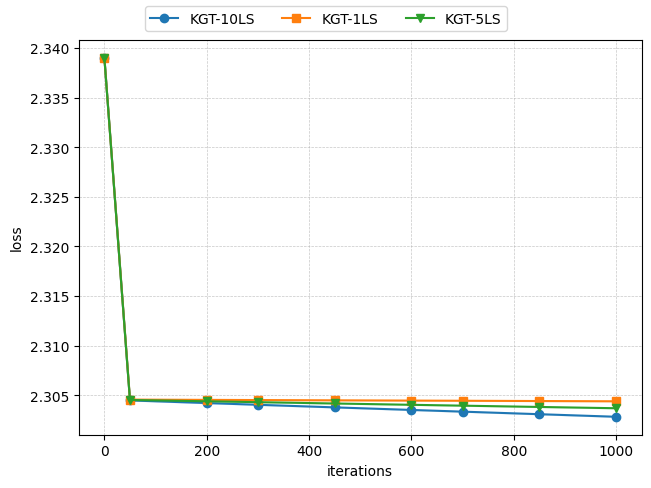

In [6]:
algorithms_to_include = [
    # "DGD",
    "KGT",
    # "LED",
    # "LT-ADMM-10",
    # "LT-ADMM-5",
    # "LT-ADMM-1",
    # "LT-ADMM-VR",
    # "ProxSkip",
]
new_metrics_result = benchmark.MetricResult(None, metrics_result.table_metrics, metrics_result.plot_metrics, None, None)

# Only include certain algorithms
def issubstring(substring: str):
    return any(alg in substring for alg in algorithms_to_include)


new_metrics_result.agent_metrics = {
    alg: metrics for alg, metrics in metrics_result.agent_metrics.items() if issubstring(alg.name)
}
new_metrics_result.table_results = {
    alg: table for alg, table in metrics_result.table_results.items() if issubstring(alg.name)
}
new_metrics_result.plot_results = {alg: plot for alg, plot in metrics_result.plot_results.items() if issubstring(alg.name)}
benchmark.display_metrics(metrics_result=new_metrics_result)

[04/02/26 02:48:51] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=879391;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=462244;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=48522;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=732028;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | Metric (statistic)      | LED-10LS            | LED-1LS             |               
                             LED-5LS             |                                                                 
                             +=========================+=====================+=====================+=              
                             ====================+                                                                 
                             | consensus error (min)   | 3.75e-07 ± 5.46e-08 | 9.22e-08 ± 7.83e-09 |               
                             3.05e-07 ± 4.17e-08 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (avg)   | 3.94e-07 ± 4.95e-08 | 9.78e-08 ± 5.32e-09 |               
                             3.22e-07 ± 2.61e-08 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (max)   | 4.18e-07 ± 6.62e-08 | 1.03e-07 ± 6.87e-09 |               
                             3.36e-07 ± 3.78e-08 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (avg) | 3.20e+05 ± 0.00e+00 | 3.20e+04 ± 0.00e+00 |               
                             1.60e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (sum) | 1.60e+06 ± 0.00e+00 | 1.60e+05 ± 0.00e+00 |               
                             8.00e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (avg)  | 4.00e+03 ± 0.00e+00 | 4.00e+03 ± 0.00e+00 |               
                             4.00e+03 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (sum)  | 2.00e+04 ± 0.00e+00 | 2.00e+04 ± 0.00e+00 |               
                             2.00e+04 ± 0.00e+00 |                                                

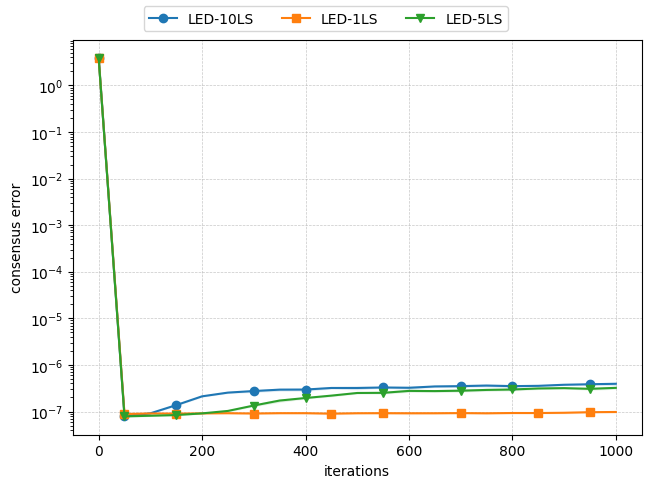

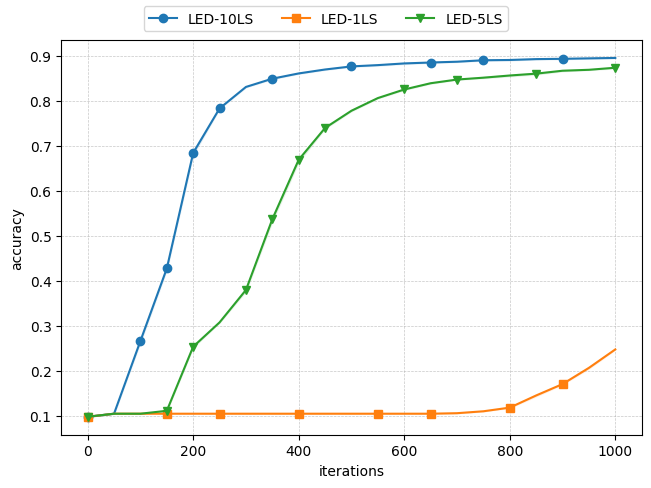

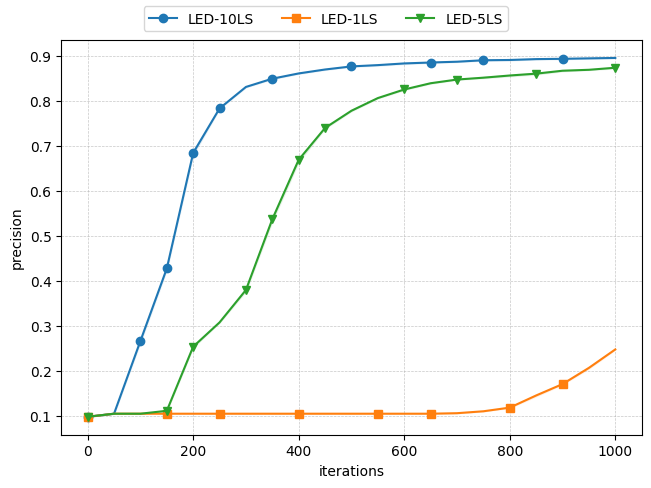

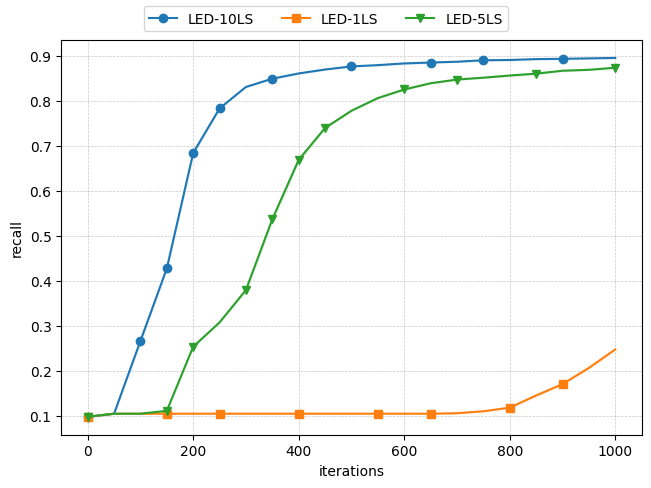

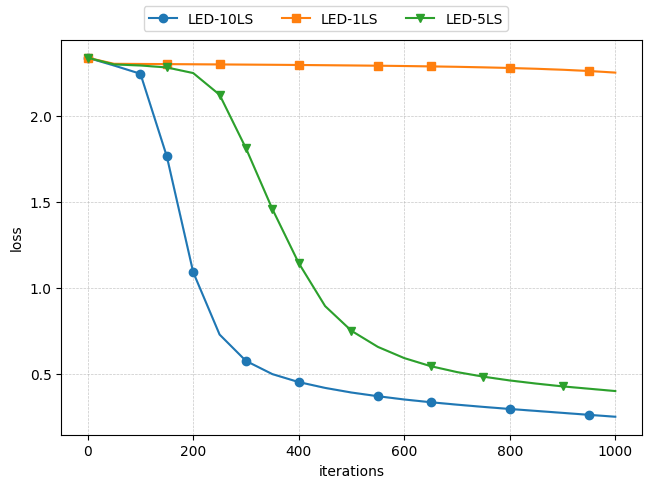

In [7]:
algorithms_to_include = [
    # "DGD",
    # "KGT",
    "LED",
    # "LT-ADMM-10",
    # "LT-ADMM-5",
    # "LT-ADMM-1",
    # "LT-ADMM-VR",
    # "ProxSkip",
]
new_metrics_result = benchmark.MetricResult(None, metrics_result.table_metrics, metrics_result.plot_metrics, None, None)

# Only include certain algorithms
def issubstring(substring: str):
    return any(alg in substring for alg in algorithms_to_include)


new_metrics_result.agent_metrics = {
    alg: metrics for alg, metrics in metrics_result.agent_metrics.items() if issubstring(alg.name)
}
new_metrics_result.table_results = {
    alg: table for alg, table in metrics_result.table_results.items() if issubstring(alg.name)
}
new_metrics_result.plot_results = {alg: plot for alg, plot in metrics_result.plot_results.items() if issubstring(alg.name)}
benchmark.display_metrics(metrics_result=new_metrics_result)

[04/02/26 02:48:56] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=449597;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=265874;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=655738;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=99994;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | Metric (statistic)      | LT-ADMM-10LS        | LT-ADMM-1LS         |               
                             LT-ADMM-5LS         |                                                                 
                             +=========================+=====================+=====================+=              
                             ====================+                                                                 
                             | consensus error (min)   | 2.45e-02 ± 1.73e-03 | 4.39e-03 ± 1.54e-03 |               
                             2.54e-02 ± 2.64e-03 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (avg)   | 2.97e-02 ± 4.84e-03 | 5.99e-03 ± 1.87e-03 |               
                             3.53e-02 ± 4.21e-03 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (max)   | 3.46e-02 ± 9.19e-03 | 7.82e-03 ± 4.28e-03 |               
                             4.19e-02 ± 7.69e-03 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (avg) | 3.20e+05 ± 0.00e+00 | 3.20e+04 ± 0.00e+00 |               
                             1.60e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (sum) | 1.60e+06 ± 0.00e+00 | 1.60e+05 ± 0.00e+00 |               
                             8.00e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (avg)  | 4.00e+03 ± 0.00e+00 | 4.00e+03 ± 0.00e+00 |               
                             4.00e+03 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (sum)  | 2.00e+04 ± 0.00e+00 | 2.00e+04 ± 0.00e+00 |               
                             2.00e+04 ± 0.00e+00 |                                                

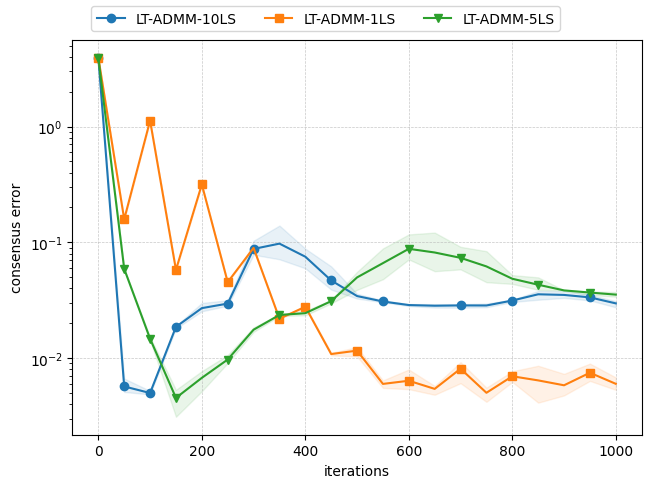

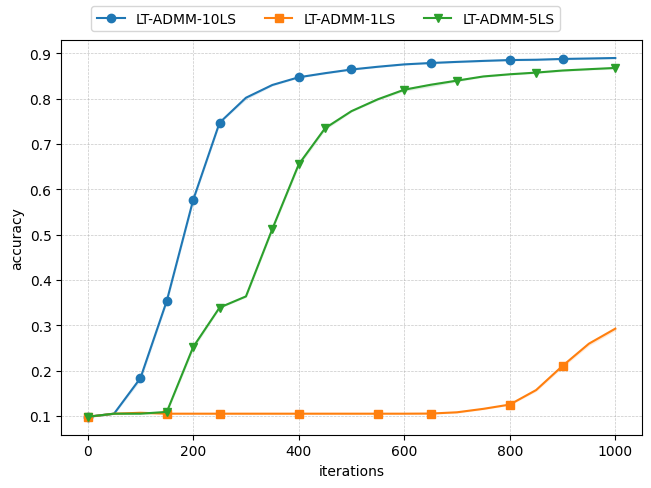

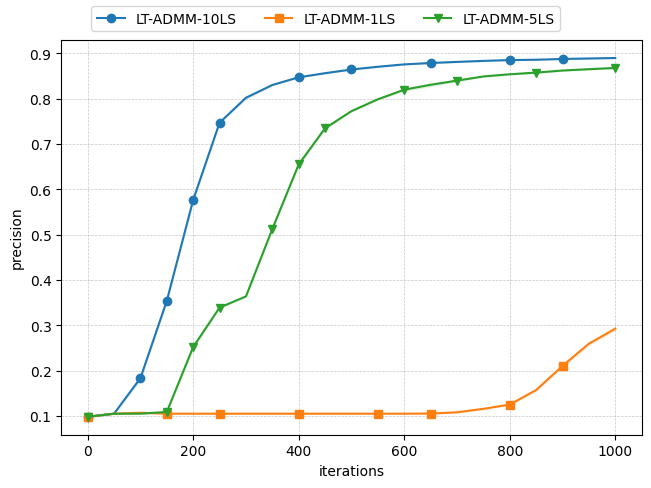

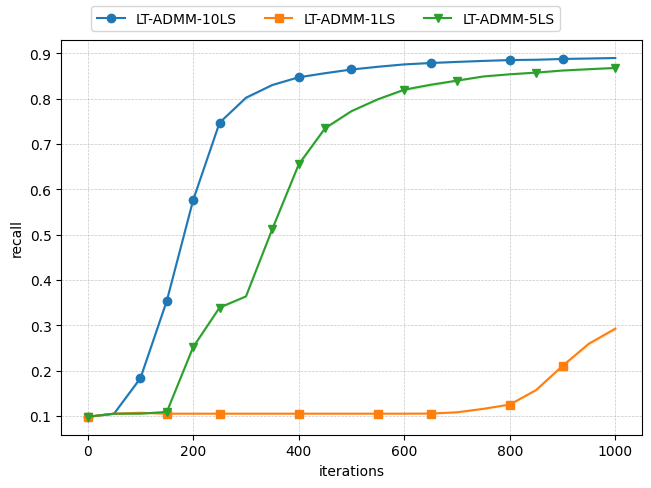

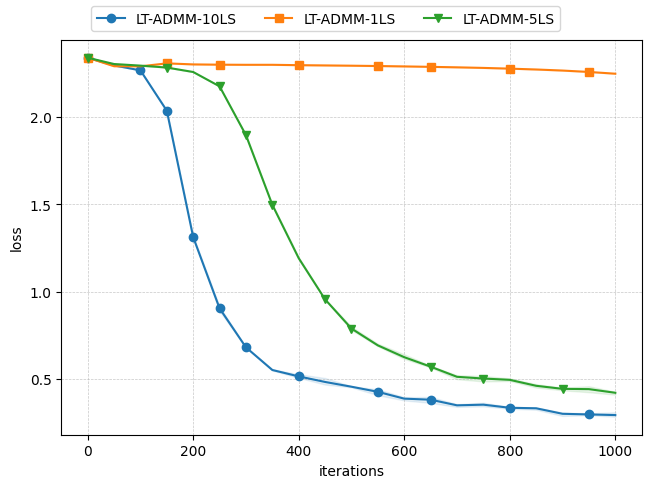

In [8]:
algorithms_to_include = [
    # "DGD",
    # "KGT",
    # "LED",
    "LT-ADMM-10",
    "LT-ADMM-5",
    "LT-ADMM-1",
    # "LT-ADMM-VR",
    # "ProxSkip",
]
new_metrics_result = benchmark.MetricResult(None, metrics_result.table_metrics, metrics_result.plot_metrics, None, None)

# Only include certain algorithms
def issubstring(substring: str):
    return any(alg in substring for alg in algorithms_to_include)


new_metrics_result.agent_metrics = {
    alg: metrics for alg, metrics in metrics_result.agent_metrics.items() if issubstring(alg.name)
}
new_metrics_result.table_results = {
    alg: table for alg, table in metrics_result.table_results.items() if issubstring(alg.name)
}
new_metrics_result.plot_results = {alg: plot for alg, plot in metrics_result.plot_results.items() if issubstring(alg.name)}
benchmark.display_metrics(metrics_result=new_metrics_result)

[04/02/26 02:49:06] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=626016;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=159647;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=141031;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=46543;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | Metric (statistic)      | LT-ADMM-VR-10LS     | LT-ADMM-VR-1LS      |               
                             LT-ADMM-VR-5LS      |                                                                 
                             +=========================+=====================+=====================+=              
                             ====================+                                                                 
                             | consensus error (min)   | 1.67e-01 ± 7.67e-02 | 8.85e-04 ± 2.29e-04 |               
                             2.46e-01 ± 4.59e-02 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (avg)   | 2.54e-01 ± 2.85e-02 | 1.08e-03 ± 5.34e-04 |               
                             4.71e-01 ± 1.78e-02 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (max)   | 3.40e-01 ± 7.82e-02 | 1.27e-03 ± 1.02e-03 |               
                             5.89e-01 ± 3.37e-02 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (avg) | 6.40e+05 ± 0.00e+00 | 6.40e+04 ± 0.00e+00 |               
                             3.20e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (sum) | 3.20e+06 ± 0.00e+00 | 3.20e+05 ± 0.00e+00 |               
                             1.60e+06 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (avg)  | 4.00e+03 ± 0.00e+00 | 4.00e+03 ± 0.00e+00 |               
                             4.00e+03 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (sum)  | 2.00e+04 ± 0.00e+00 | 2.00e+04 ± 0.00e+00 |               
                             2.00e+04 ± 0.00e+00 |                                                

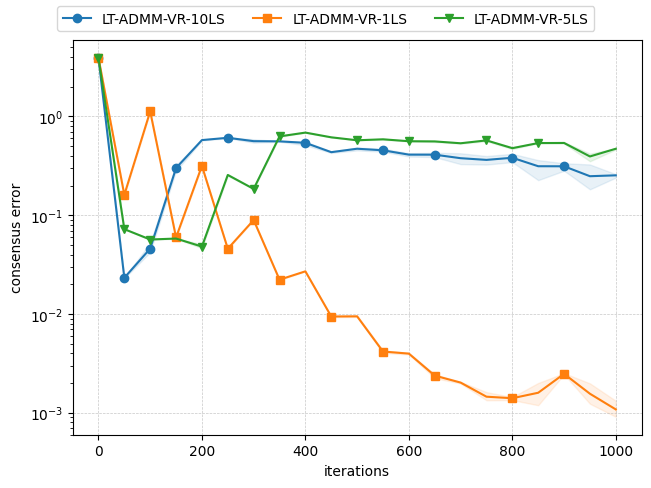

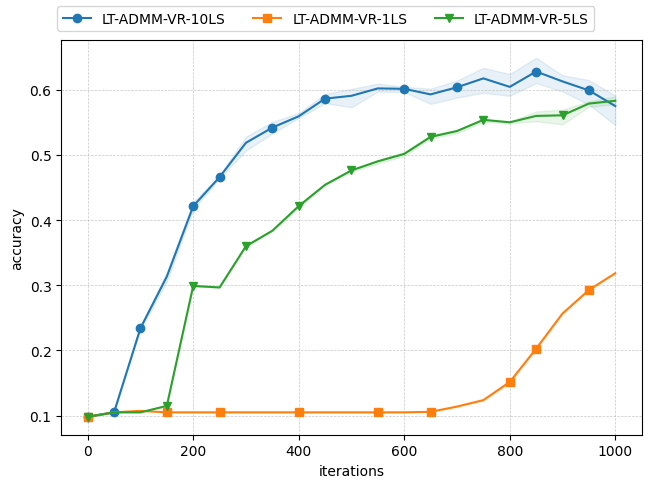

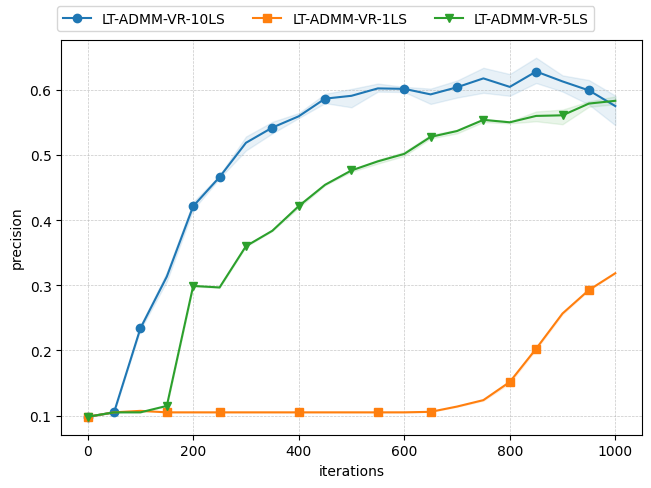

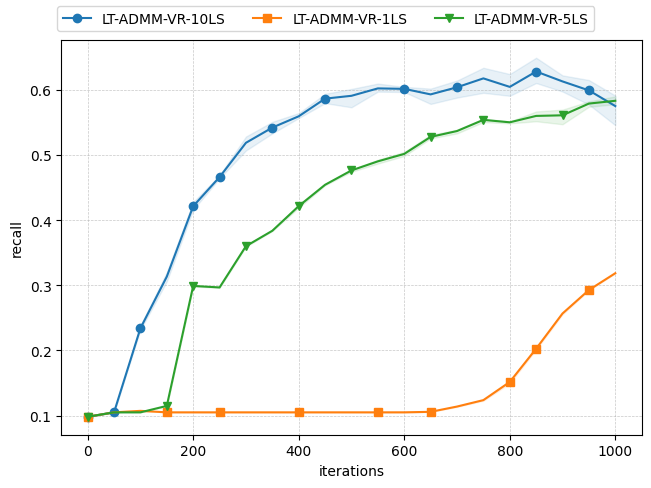

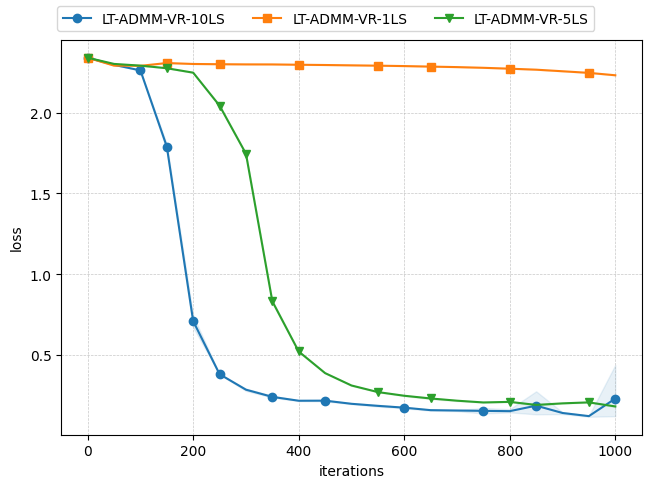

In [9]:
algorithms_to_include = [
    # "DGD",
    # "KGT",
    # "LED",
    # "LT-ADMM-10",
    # "LT-ADMM-5",
    # "LT-ADMM-1",
    "LT-ADMM-VR",
    # "ProxSkip",
]
new_metrics_result = benchmark.MetricResult(None, metrics_result.table_metrics, metrics_result.plot_metrics, None, None)

# Only include certain algorithms
def issubstring(substring: str):
    return any(alg in substring for alg in algorithms_to_include)


new_metrics_result.agent_metrics = {
    alg: metrics for alg, metrics in metrics_result.agent_metrics.items() if issubstring(alg.name)
}
new_metrics_result.table_results = {
    alg: table for alg, table in metrics_result.table_results.items() if issubstring(alg.name)
}
new_metrics_result.plot_results = {alg: plot for alg, plot in metrics_result.plot_results.items() if issubstring(alg.name)}
benchmark.display_metrics(metrics_result=new_metrics_result)

[04/02/26 02:49:18] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=698046;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=369334;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=202435;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=316766;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | Metric (statistic)      | ProxSkip-0.2CP      | ProxSkip-0.5CP      |               
                             ProxSkip-0.9CP      |                                                                 
                             +=========================+=====================+=====================+=              
                             ====================+                                                                 
                             | consensus error (min)   | 1.31e-03 ± 1.54e-03 | 1.22e-03 ± 1.02e-03 |               
                             3.89e-04 ± 1.25e-04 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (avg)   | 2.31e-03 ± 2.59e-03 | 1.98e-03 ± 2.02e-03 |               
                             7.44e-04 ± 3.55e-04 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | consensus error (max)   | 3.56e-03 ± 3.87e-03 | 3.73e-03 ± 3.35e-03 |               
                             1.46e-03 ± 6.72e-04 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (avg) | 3.20e+04 ± 0.00e+00 | 3.20e+04 ± 0.00e+00 |               
                             3.20e+04 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr gradient calls (sum) | 1.60e+05 ± 0.00e+00 | 1.60e+05 ± 0.00e+00 |               
                             1.60e+05 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (avg)  | 7.72e+02 ± 1.50e+01 | 1.99e+03 ± 8.39e+01 |               
                             3.61e+03 ± 3.83e+01 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+                                                                 
                             | nr sent messages (sum)  | 3.86e+03 ± 7.50e+01 | 9.97e+03 ± 4.19e+02 |               
                             1.80e+04 ± 1.92e+02 |                                               

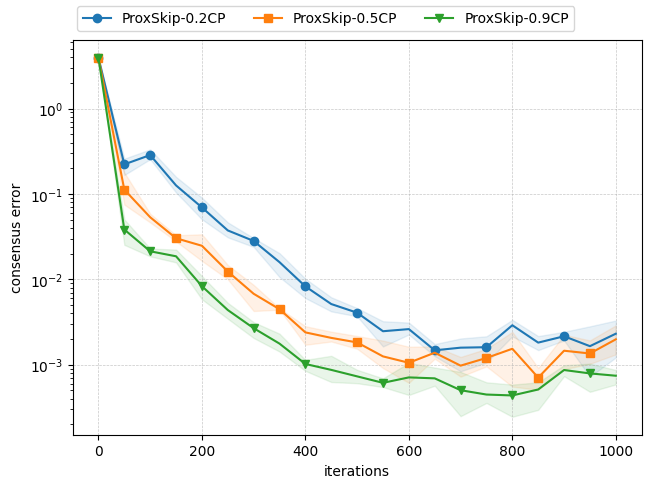

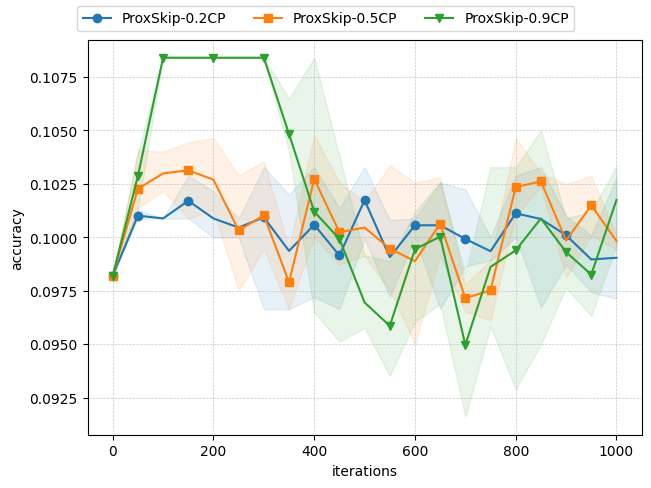

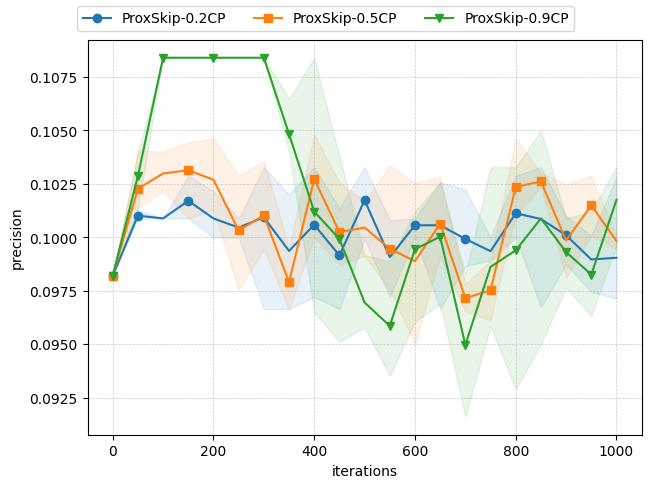

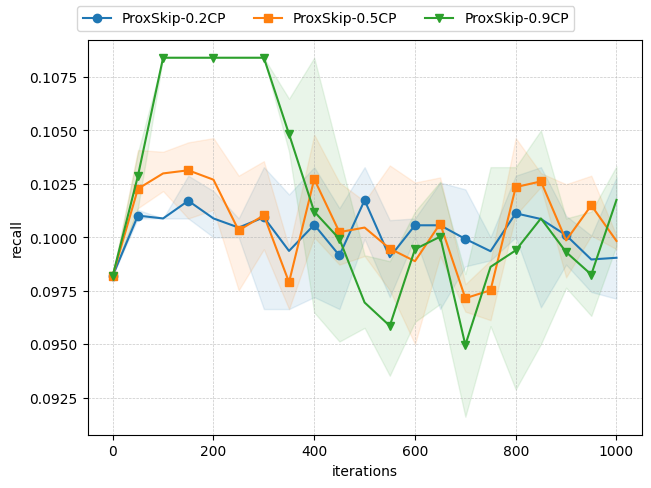

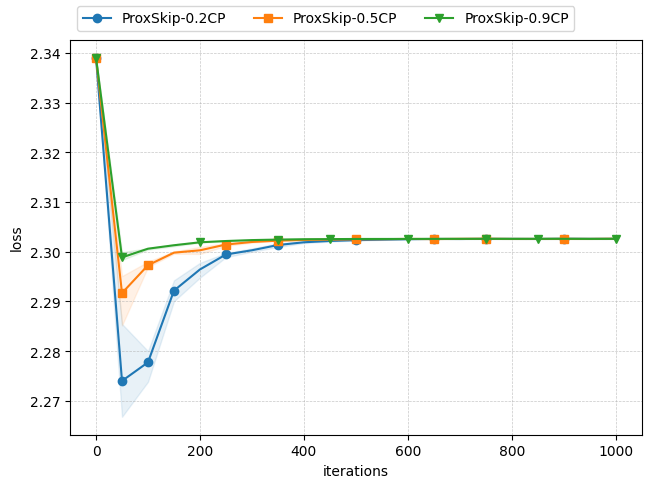

In [10]:
algorithms_to_include = [
    # "DGD",
    # "KGT",
    # "LED",
    # "LT-ADMM-10",
    # "LT-ADMM-5",
    # "LT-ADMM-1",
    # "LT-ADMM-VR",
    "ProxSkip",
]
new_metrics_result = benchmark.MetricResult(None, metrics_result.table_metrics, metrics_result.plot_metrics, None, None)

# Only include certain algorithms
def issubstring(substring: str):
    return any(alg in substring for alg in algorithms_to_include)


new_metrics_result.agent_metrics = {
    alg: metrics for alg, metrics in metrics_result.agent_metrics.items() if issubstring(alg.name)
}
new_metrics_result.table_results = {
    alg: table for alg, table in metrics_result.table_results.items() if issubstring(alg.name)
}
new_metrics_result.plot_results = {alg: plot for alg, plot in metrics_result.plot_results.items() if issubstring(alg.name)}
benchmark.display_metrics(metrics_result=new_metrics_result)